# 11 - Group Fitting

This notebook fits one shared simulation mechanism across multiple measured CVs. It first fits one Ar CV, then uses an Ar scan-rate group fit to refine shared `EE` potentials and tied diffusion, and finally fits a CO2/PhOH concentration series with an EEC' mechanism.


## Import eCAT And Set Paths

Use this notebook after the simulation intro, when the single-CV mechanism and parameter conventions are familiar.


In [1]:
from copy import deepcopy
import importlib.util
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
HAS_ELECTROKITTY = importlib.util.find_spec("electrokitty") is not None
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))
print("ElectroKitty available:", HAS_ELECTROKITTY)
if not HAS_ELECTROKITTY:
    print('Install in this notebook with: %pip install "ecat[simulation]"; then restart the kernel before running fit cells.')

eCAT version: 0.1.0b5
Example data: examples/data/fe_phoh_cv
Text files: 13
ElectroKitty available: True


## Load And Select Candidate Traces

The group fits use public eCAT filters so the selected traces are reproducible. PhOH CVs are scaled against one shared Ar/Fc segment-2 wave before any fitting input is trimmed. Ar CVs use the `0` to `-1.5 V` fitting window; PhOH CVs use expanded waveform trimming from `-1` to `-1.7 V` during `cv_data()` conversion.


In [2]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "keyword",
    "reference keyword": "Fc",
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "electrode diameter": 0.3,
    "print": False,
})
cvs = e.filter(cvs, {"segments": 3}, {"print": False})

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

phoh_co2 = e.filter(cvs, {
    "gas": "CO2",
    "compounds": "PhOH",
}, {"logic": "AND", "print": False})

scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": True})

ar_reference_cv = e.filter(scan_series, {"scan rate": 0.1}, {"print": False})[0]
phoh_group = e.filter(phoh_co2, {"scan rate": 0.1}, {"print": True})
phoh_28m_cv = e.filter(phoh_group, {"species": "2.8M PhOH"}, {"print": False})[0]
AR_CV_POTENTIAL_WINDOW = [-0.7, -1.7]
PHOH_CV_POTENTIAL_WINDOW = [-1.0, -1.7]
AR_CV_WINDOW_OPTIONS = {
    "potential window": AR_CV_POTENTIAL_WINDOW,
    "trim mode": "expand",
}
PHOH_CV_WINDOW_OPTIONS = {
    "potential window": PHOH_CV_POTENTIAL_WINDOW,
    "trim mode": "expand",
}



=== Sorted Objects ===
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Scan Rate
[0],25 mV/s
[1],50 mV/s
[2],100 mV/s
[3],500 mV/s
[4],1 V/s


=== Filtered Objects (Include) ===
Filtering Criteria: (scan rate: 0.1)
Matched Objects: 4 / 4
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds
[0],100 mM PhOH
[1],560 mM PhOH
[2],1 M PhOH
[3],2.8 M PhOH


## Scale PhOH CVs Against One Ar/Fc Wave

Use the same Ar trace for every CO2/PhOH CV. The Fc wave is measured on segment 2 before trimming, then `scale_current()` applies that current scale to raw PhOH current copies. These scaled CV copies are what enter the EEC' group fit.

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds,Scale Factor
[0],100 mM PhOH,0.6979
[1],560 mM PhOH,0.7401
[2],1 M PhOH,0.8338
[3],2.8 M PhOH,1.154


,Label,Scale Factor,Reference ip0 / A,Measured ip0 / A
0,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mM...,0.697855,0.00012,0.000172
1,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mM...,0.740098,0.00012,0.000162
2,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhO...,0.833836,0.00012,0.000144
3,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MP...,1.154177,0.00012,0.000104


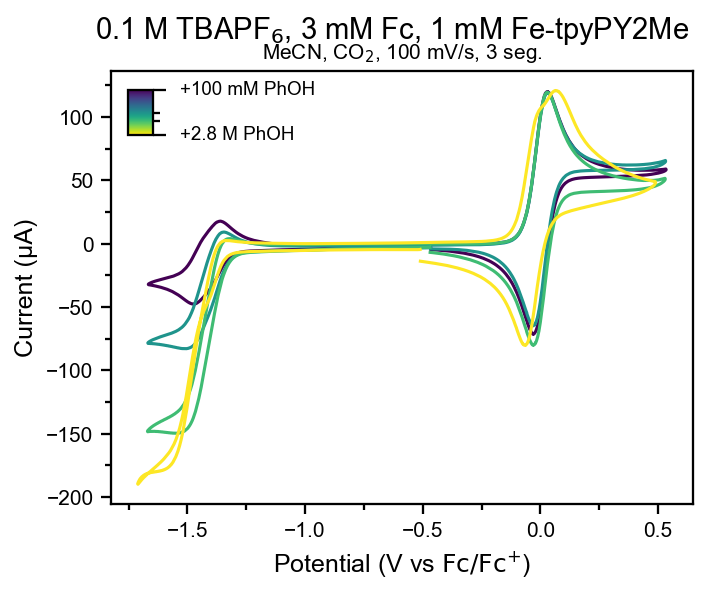

In [3]:
FC_SCALE_OPTIONS = {
    "reference cv": ar_reference_cv,
    "reference mode": "single",
    "segment": 2,
    "guess potential": 0.0,
    "print": True,
}

phoh_group_scaled = e.scale_current(phoh_group, FC_SCALE_OPTIONS)
phoh_28m_cv_scaled = e.filter(phoh_group_scaled, {"species": "2.8M PhOH"}, {"print": False})[0]

e.multiplot(phoh_group_scaled, {'print': False})

pd.DataFrame({
    "Label": [cv.name for cv in phoh_group_scaled],
    "Scale Factor": [getattr(cv, "current_scale_factor", None) for cv in phoh_group_scaled],
    "Reference ip0 / A": [getattr(cv, "current_scale_target_ip", [None])[0] for cv in phoh_group_scaled],
    "Measured ip0 / A": [getattr(cv, "current_scale_source_ip", [None])[0] for cv in phoh_group_scaled],
})

## Fit 1: Single Ar CV Seed

Start with one Ar CV at `0.1 V/s`. This gives reasonable starting values before fitting a scan-rate series. The cell block is spelled out here so the defaults are visible; later group fits use `"cell": "auto"` for the same metadata-aware behavior.


,Parameter,Control,Value
0,Fit strategy,method,least squares
1,Simulation backend,backend,electrokitty
2,Mechanism,mechanism,E(1):FeII=FeI ; E(1):FeI=Fe0
3,Mechanism preset,compile_mechanism(...).preset,EE
4,Residual mode,"options[""residual""]",direct
5,Final current correction,"options[""post correction""]",offset
6,Residual normalization,"options[""residual normalization""]",max abs measured
7,Evaluation budget,"options[""max nfev""]",None
8,Data points,input.E,198
9,Fit targets,"fit[""vary""]",3


,Path,Step,Parameter,Initial,Lower,Upper,Transform
0,kinetics.0.E0,0,E⁰,-1.3 V,-2.1665 V,-0.7005 V,linear
1,kinetics.1.E0,1,E⁰,-1.5 V,-2.1665 V,-0.7005 V,linear
2,"diffusion.FeII, diffusion.FeI, diffusion.Fe0",,D (tied),2e-09 m²/s,2e-11 m²/s,2e-07 m²/s,log10


,Path,Step,Parameter,Value
0,kinetics.0.alpha,0,α,0.5
1,kinetics.1.alpha,1,α,0.5
2,kinetics.0.k0,0,k⁰,0.001 m/s
3,kinetics.1.k0,1,k⁰,0.001 m/s


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,spatial,spatial.dx_fraction,Δx/xmax,fixed,0.005,
1,spatial,spatial.nx,nₓ,fixed,8,
2,spatial,spatial.viscosity,η,fixed,4.7e-07 m²/s,
3,spatial,spatial.rotation,ω,fixed,0 Hz,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,cell,cell.T,T,fixed,298.15 K,
1,cell,cell.Ru,Rᵤ,fixed,0 Ω,
2,cell,cell.Cdl,Cdl,fixed,2.58425e-05 F,
3,cell,cell.A,A,fixed,1e-05 m²,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,bulk,diffusion.FeII,D(FeII),fit-tied,2e-09 m²/s,8.30693e-10 m²/s
1,bulk,diffusion.FeI,D(FeI),fit-tied,2e-09 m²/s,8.30693e-10 m²/s
2,bulk,diffusion.Fe0,D(Fe0),fit-tied,2e-09 m²/s,8.30693e-10 m²/s
3,bulk,concentrations.bulk.FeII,[FeII],fixed,1 mol/m³,
4,bulk,concentrations.bulk.FeI,[FeI],fixed,0 mol/m³,
5,bulk,concentrations.bulk.Fe0,[Fe0],fixed,0 mol/m³,


,Group,Path,Step,Parameter,Fit Status,Initial Value,Final Value
0,kinetics,kinetics.0.E0,0,E⁰,fit,-1.3 V,-1.37485 V
1,kinetics,kinetics.0.k0,0,k⁰,fixed,0.001 m/s,
2,kinetics,kinetics.0.alpha,0,α,fixed,0.5,
3,kinetics,kinetics.1.E0,1,E⁰,fit,-1.5 V,-1.46552 V
4,kinetics,kinetics.1.k0,1,k⁰,fixed,0.001 m/s,
5,kinetics,kinetics.1.alpha,1,α,fixed,0.5,


,Parameter,Value
0,Data Points,198
1,Fit Parameters,3
2,Degrees of Freedom,195
3,Objective Evaluations,78
4,Optimizer Cost,1.77124
5,Final Optimizer Cost,1.77124
6,Residual Norm,4.19158e-05 A
7,RMSE,2.97883e-06 A
8,MAE,2.64633e-06 A
9,Max |Residual|,7.04651e-06 A


,Parameter,Value
0,Current Sign,1
1,Baseline Intercept,-5.23188e-06 A


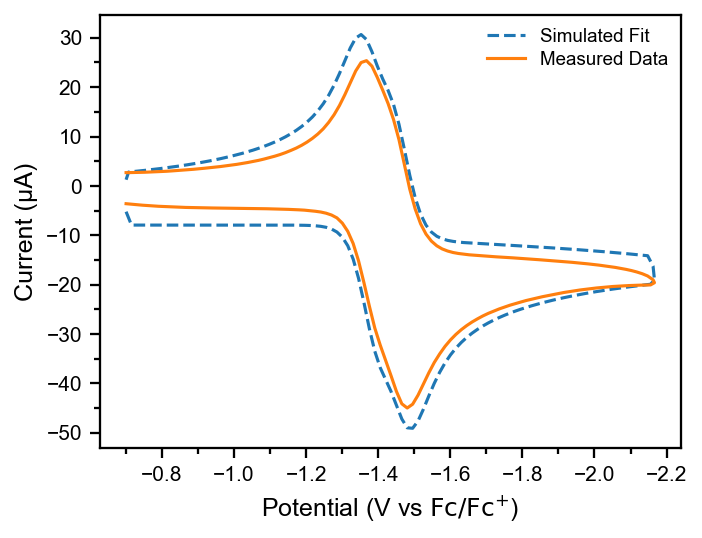

In [4]:
single_ar_fit = None
if not HAS_ELECTROKITTY:
    print("SKIP: single Ar fit requires ElectroKitty.")
else:
    AR_FIT_STRIDE = 15
    CO2_FIT_STRIDE = 15

    ar_ee_params = {
        "concentrations": {"bulk": {"FeII": 1.0, "FeI": 0.0, "Fe0": 0.0}},
        "diffusion": {"FeII": 2e-9, "FeI": 2e-9, "Fe0": 2e-9},
        "kinetics": [
            {"E0": -1.3, "k0": 1e-3, "alpha": 0.5},
            {"E0": -1.5, "k0": 1e-3, "alpha": 0.5},
        ],
        "cell": {"T": 298.15, "Ru": 0.0, "Cdl": "auto", "A": 1e-5},
        "spatial": "fast",
    }

    single_ar_fit = e.simulation.fit_cv(
        ar_reference_cv,
        "EE",
        ar_ee_params,
        fit={
            "vary": ["E0_0", "E0_1", "D"],
            "fixed": {"alpha_*": 0.5, "k0_*": 1e-3},
            "bounds": "auto",
            "transform": "auto",
        },
        options={
            "cv data": {**AR_CV_WINDOW_OPTIONS, "stride": AR_FIT_STRIDE, "estimate Cdl": "auto"},
            "plot": True,
            "post correction": "offset",
            "print stats": False,
            "print corrections": False,
            "print progress": False,
        },
    )
    single_ar_fit.show({"print setup": False, "print stats": True, "print corrections": True, "print params": False, "print simulation": False})

## Fit 2: Ar Scan-Rate Group Fit

Fit the Ar scan-rate series to refine the two formal potentials and one tied diffusion coefficient. This cell switches to `"cell": "auto"`, so `Cdl`, area, temperature, and resistance are populated from each source CV or defaults. `Cdl` and `Ru` are per-CV inputs but remain fixed because they are not listed in `fit["vary"]`.


,CV,Label,Source,Scan Rate,Input Concentrations,Points
0,1,25 mV/s,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_25mVs,0.025 V/s,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me,198
1,2,50 mV/s,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_50mVs,0.05 V/s,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me,198
2,3,100 mV/s,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_100mVs,0.1 V/s,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me,198
3,4,500 mV/s,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_500mVs,0.5 V/s,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me,198
4,5,1 V/s,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_1Vs,1 V/s,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me,198


,Parameter,Value
0,Data Points,990
1,Fit Parameters,3
2,Degrees of Freedom,987
3,Objective Evaluations,39
4,Optimizer Cost,15.0419
5,Final Optimizer Cost,15.0419
6,Residual Norm,0.000176135 A
7,RMSE,5.59794e-06 A
8,MAE,4.34452e-06 A
9,Max |Residual|,2.72776e-05 A


,CV,Label,Correction,Value
0,1,25 mV/s,Baseline Intercept,-5.85671e-06 A
1,2,50 mV/s,Baseline Intercept,-5.29559e-06 A
2,3,100 mV/s,Baseline Intercept,-5.11547e-06 A
3,4,500 mV/s,Baseline Intercept,-7.15834e-06 A
4,5,1 V/s,Baseline Intercept,-1.01541e-05 A


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,spatial,spatial.dx_fraction,Δx/xmax,fixed,0.005,
1,spatial,spatial.nx,nₓ,fixed,8,
2,spatial,spatial.viscosity,η,fixed,4.7e-07 m²/s,
3,spatial,spatial.rotation,ω,fixed,0 Hz,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,cell,cell.Cdl,Cdl,fixed,3.7664e-05 F,
1,cell,cell.T,T,fixed,298 K,
2,cell,cell.A,A,fixed,7.06858e-06 m²,
3,cell,cell.Ru,Rᵤ,fixed,0 Ω,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,bulk,diffusion.FeII,D(FeII),fit-tied,8.30693e-10 m²/s,1.75597e-09 m²/s
1,bulk,diffusion.FeI,D(FeI),fit-tied,8.30693e-10 m²/s,1.75597e-09 m²/s
2,bulk,diffusion.Fe0,D(Fe0),fit-tied,8.30693e-10 m²/s,1.75597e-09 m²/s
3,bulk,concentrations.bulk.FeII,[FeII],fixed,1 mol/m³,
4,bulk,concentrations.bulk.FeI,[FeI],fixed,0 mol/m³,
5,bulk,concentrations.bulk.Fe0,[Fe0],fixed,0 mol/m³,


,Group,Path,Step,Parameter,Fit Status,Initial Value,Final Value
0,kinetics,kinetics.0.E0,0,E⁰,fit,-1.37485 V,-1.37256 V
1,kinetics,kinetics.0.k0,0,k⁰,fixed,0.001 m/s,
2,kinetics,kinetics.0.alpha,0,α,fixed,0.5,
3,kinetics,kinetics.1.E0,1,E⁰,fit,-1.46552 V,-1.46988 V
4,kinetics,kinetics.1.k0,1,k⁰,fixed,0.001 m/s,
5,kinetics,kinetics.1.alpha,1,α,fixed,0.5,


,CV,Label,Path,Parameter,Fit Status,Initial Value,Final Value,Source
0,1,25 mV/s,cell.Cdl,Cdl,fixed,3.7664e-05 F,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_25mVs
1,1,25 mV/s,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_25mVs
2,2,50 mV/s,cell.Cdl,Cdl,fixed,4.426e-05 F,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_50mVs
3,2,50 mV/s,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_50mVs
4,3,100 mV/s,cell.Cdl,Cdl,fixed,2.58425e-05 F,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_100mVs
5,3,100 mV/s,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_100mVs
6,4,500 mV/s,cell.Cdl,Cdl,fixed,2.4302e-05 F,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_500mVs
7,4,500 mV/s,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_500mVs
8,5,1 V/s,cell.Cdl,Cdl,fixed,1.99125e-05 F,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_1Vs
9,5,1 V/s,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_1Vs


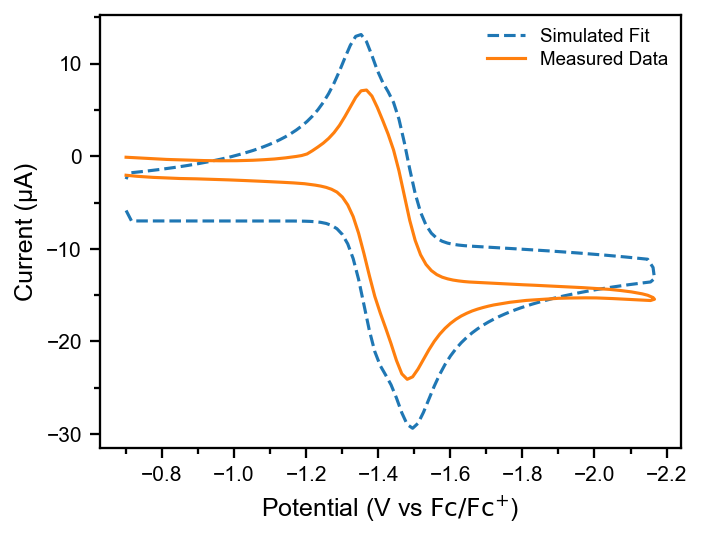

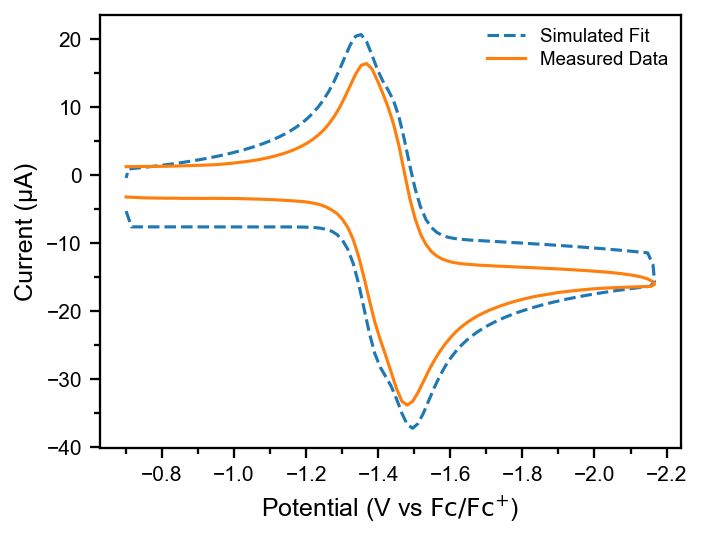

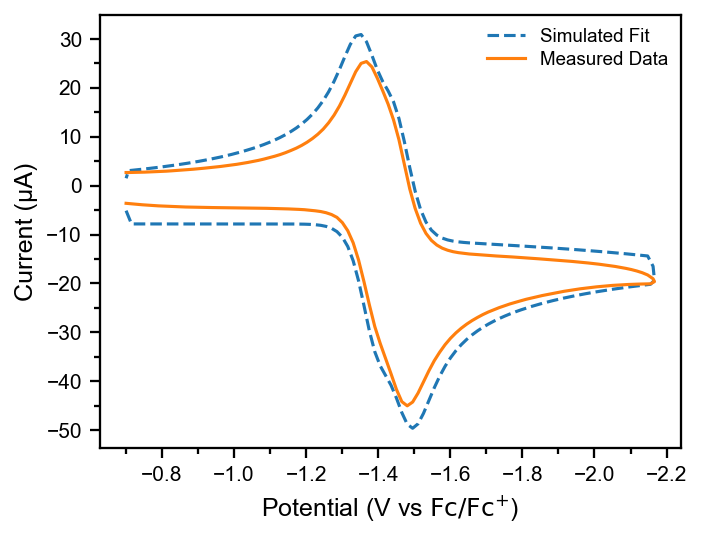

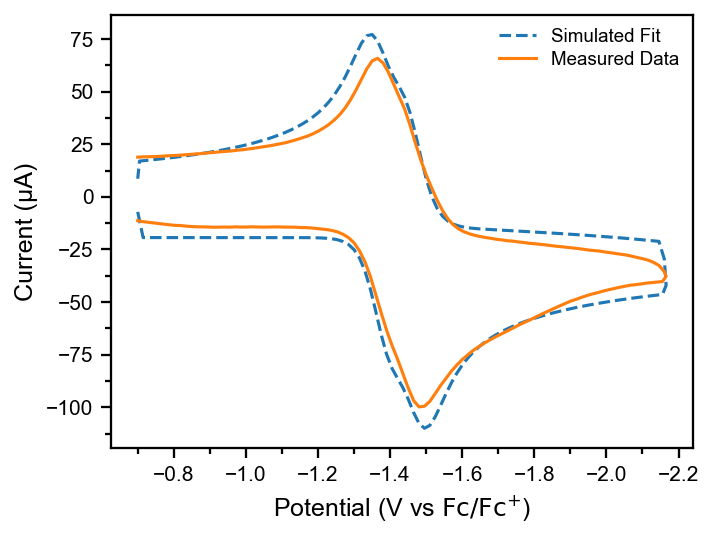

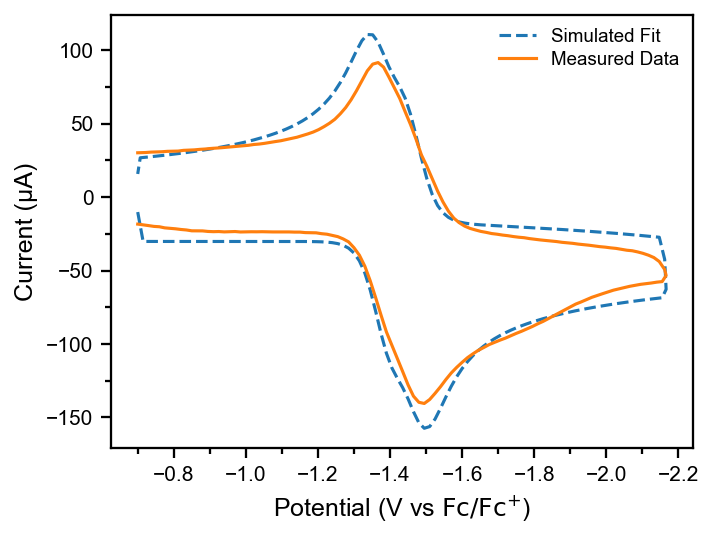

In [5]:
ar_scan_fit = None
if single_ar_fit is None:
    print("SKIP: Ar scan-rate group fit needs the single Ar fit result.")
else:
    ar_scan_params = deepcopy(single_ar_fit.best_params)
    ar_scan_params["cell"] = "auto"

    ar_scan_fit = e.simulation.fit_cvs(
        scan_series,
        "EE",
        ar_scan_params,
        fit={
            "vary": ["E0_0", "E0_1", "D"],
            "fixed": {"alpha_*": 0.5, "k0_*": 1e-3},
            "bounds": "auto",
            "transform": "auto",
        },
        per_cv=["cell.Cdl", "cell.Ru"],
        options={
            "cv data": {**AR_CV_WINDOW_OPTIONS, "stride": AR_FIT_STRIDE, "estimate Cdl": "auto"},
            "plot": True,
            "post correction": "offset",
            "print setup": True,
            "print stats": True,
            "print corrections": True,
            "print params": True,
            "print progress": False,
            "print simulation": False,
        },
    )

## Build The EEC' Concentration-Fit Starting Point

Start from the Ar group-fit parameters. Add substrate/product species and use the Ar-fitted diffusion scale for them unless a better value is known.


In [6]:
group_params = None
if ar_scan_fit is None:
    print("SKIP: EEC' concentration setup needs the Ar scan-rate group fit result.")
else:
    group_params = deepcopy(ar_scan_fit.best_params)
    group_params.setdefault("concentrations", {}).setdefault("bulk", {}).update({
        "Substrate": 1.0,
        "Product": 0.0,
    })
    reference_diffusion = next(iter(group_params.get("diffusion", {"FeII": 1e-9}).values()))
    group_params.setdefault("diffusion", {}).update({
        "Substrate": reference_diffusion,
        "Product": reference_diffusion,
    })
    group_params["reactions"] = [{"kf": 1.0, "kb": 0.0}]
    group_params["cell"] = "auto"

    eecat_mechanism = (
        "E(1):FeII=FeI\n"
        "E(1):FeI=Fe0\n"
        "C:Fe0+Substrate>FeI+Product"
    )

    e.simulation.simulate_cv(
        e.simulation.cv_data(phoh_28m_cv_scaled, {**PHOH_CV_WINDOW_OPTIONS, "stride": CO2_FIT_STRIDE, "estimate Cdl": "auto"}),
        eecat_mechanism,
        group_params,
        options={"plot": False, "check params": True},
    ).show({"print setup": True, "print params": "compact"})

,Status,Path,Check,Detail
0,OK,,No parameter issues detected,


,Parameter,Value
0,Backend,electrokitty
1,Mechanism Preset,raw
2,Mechanism,E(1):FeII=FeI E(1):FeI=Fe0 C:Fe0+Substrate>FeI+Product
3,Current Sign,1
4,Points,97
5,Scan Rate,0.1 V/s
6,Segments,2
7,Incubation Time,0 s
8,Quiet Time,2 s
9,Potential Range,-1.711 V to -1 V


,Group,Path,Parameter,Value
0,spatial,spatial.dx_fraction,Δx/xmax,0.005
1,spatial,spatial.nx,nₓ,8
2,spatial,spatial.viscosity,η,4.7e-07 m²/s
3,spatial,spatial.rotation,ω,0 Hz


,Group,Path,Parameter,Value
0,cell,cell.Cdl,Cdl,2.68848e-05 F
1,cell,cell.T,T,298 K
2,cell,cell.A,A,7.06858e-06 m²
3,cell,cell.Ru,Rᵤ,0 Ω


,Phase,Species,Amount,Diffusion
0,bulk,FeII,1 mol/m³,1.75597e-09 m²/s
1,bulk,FeI,0 mol/m³,1.75597e-09 m²/s
2,bulk,Fe0,0 mol/m³,1.75597e-09 m²/s
3,bulk,Substrate,1 mol/m³,1.75597e-09 m²/s
4,bulk,Product,0 mol/m³,1.75597e-09 m²/s


,Group,Step,E⁰,k⁰,α,k₁,k₋₁
0,kinetics,0,-1.37256 V,0.001 m/s,0.5,,
1,kinetics,1,-1.46988 V,0.001 m/s,0.5,,
2,reactions,0,,,,1 s⁻¹,0 s⁻¹


## Fit 3: CO2/PhOH Concentration Group Fit

Fit the scaled PhOH concentration series. The group setup table should show PhOH mapped to `Substrate`, while `Per-CV Fitting Params` shows the actual per-dataset concentration values in mol/m^3. The scaled CV copies enter `fit_cvs()`, so the fitting algorithm only sees Fc-standardized currents in the trimmed simulation window.


,CV,Label,Source,Input Concentrations,Mapped Concentrations,Points
0,1,100 mM PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me; 100 mM PhOH,PhOH → Substrate: 100 mol/m³,91
1,2,560 mM PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mMPhOH_-1.2_to_1V_100mVs,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me; 560 mM PhOH,PhOH → Substrate: 560 mol/m³,92
2,3,1 M PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhOH_-1.2_to_1V_100mVs,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me; 1 M PhOH,PhOH → Substrate: 1000 mol/m³,92
3,4,2.8 M PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MPhOH_-1.2_to_1V_100mVs,0.1 M TBAPF6; 3 mM Fc; 1 mM Fe-tpyPY2Me; 2.8 M PhOH,PhOH → Substrate: 2800 mol/m³,97


,Parameter,Value
0,Data Points,372
1,Fit Parameters,1
2,Degrees of Freedom,371
3,Objective Evaluations,15
4,Optimizer Cost,9.56865
5,Final Optimizer Cost,9.56865
6,Residual Norm,0.000358207 A
7,RMSE,1.85722e-05 A
8,MAE,1.54835e-05 A
9,Max |Residual|,4.56445e-05 A


,CV,Label,Correction,Value
0,1,100 mM PhOH,Baseline Intercept,5.20338e-06 A
1,2,560 mM PhOH,Baseline Intercept,5.64168e-06 A
2,3,1 M PhOH,Baseline Intercept,-1.04453e-05 A
3,4,2.8 M PhOH,Baseline Intercept,7.25048e-06 A


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,spatial,spatial.dx_fraction,Δx/xmax,fixed,0.005,
1,spatial,spatial.nx,nₓ,fixed,8,
2,spatial,spatial.viscosity,η,fixed,4.7e-07 m²/s,
3,spatial,spatial.rotation,ω,fixed,0 Hz,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,cell,cell.Cdl,Cdl,fixed,1.09773e-05 F,
1,cell,cell.T,T,fixed,298 K,
2,cell,cell.A,A,fixed,7.06858e-06 m²,
3,cell,cell.Ru,Rᵤ,fixed,0 Ω,


,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,bulk,diffusion.FeII,D(FeII),fixed,1.75597e-09 m²/s,
1,bulk,diffusion.FeI,D(FeI),fixed,1.75597e-09 m²/s,
2,bulk,diffusion.Fe0,D(Fe0),fixed,1.75597e-09 m²/s,
3,bulk,diffusion.Substrate,D(Substrate),fixed,1.75597e-09 m²/s,
4,bulk,diffusion.Product,D(Product),fixed,1.75597e-09 m²/s,
5,bulk,concentrations.bulk.FeII,[FeII],fixed,1 mol/m³,
6,bulk,concentrations.bulk.FeI,[FeI],fixed,0 mol/m³,
7,bulk,concentrations.bulk.Fe0,[Fe0],fixed,0 mol/m³,
8,bulk,concentrations.bulk.Substrate,[Substrate],fixed,1 mol/m³,
9,bulk,concentrations.bulk.Product,[Product],fixed,0 mol/m³,


,Group,Path,Step,Parameter,Fit Status,Initial Value,Final Value
0,kinetics,kinetics.0.E0,0,E⁰,fixed,-1.37256 V,
1,kinetics,kinetics.0.k0,0,k⁰,fixed,0.001 m/s,
2,kinetics,kinetics.0.alpha,0,α,fixed,0.5,
3,kinetics,kinetics.1.E0,1,E⁰,fixed,-1.46988 V,
4,kinetics,kinetics.1.k0,1,k⁰,fixed,0.001 m/s,
5,kinetics,kinetics.1.alpha,1,α,fixed,0.5,
6,reactions,reactions.0.kf,0,k₁,fit,1 s⁻¹,0.0335069 s⁻¹
7,reactions,reactions.0.kb,0,k₋₁,fixed,0 s⁻¹,


,CV,Label,Path,Parameter,Fit Status,Initial Value,Final Value,Source
0,1,100 mM PhOH,cell.Cdl,Cdl,fixed,1.09773e-05 F,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs
1,1,100 mM PhOH,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs
2,1,100 mM PhOH,concentrations.bulk.Substrate,[Substrate],fixed,100 mol/m³,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs
3,2,560 mM PhOH,cell.Cdl,Cdl,fixed,1.01467e-05 F,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mMPhOH_-1.2_to_1V_100mVs
4,2,560 mM PhOH,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mMPhOH_-1.2_to_1V_100mVs
5,2,560 mM PhOH,concentrations.bulk.Substrate,[Substrate],fixed,560 mol/m³,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mMPhOH_-1.2_to_1V_100mVs
6,3,1 M PhOH,cell.Cdl,Cdl,fixed,1.50395e-05 F,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhOH_-1.2_to_1V_100mVs
7,3,1 M PhOH,cell.Ru,Rᵤ,fixed,0 Ω,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhOH_-1.2_to_1V_100mVs
8,3,1 M PhOH,concentrations.bulk.Substrate,[Substrate],fixed,1000 mol/m³,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhOH_-1.2_to_1V_100mVs
9,4,2.8 M PhOH,cell.Cdl,Cdl,fixed,2.68848e-05 F,,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MPhOH_-1.2_to_1V_100mVs


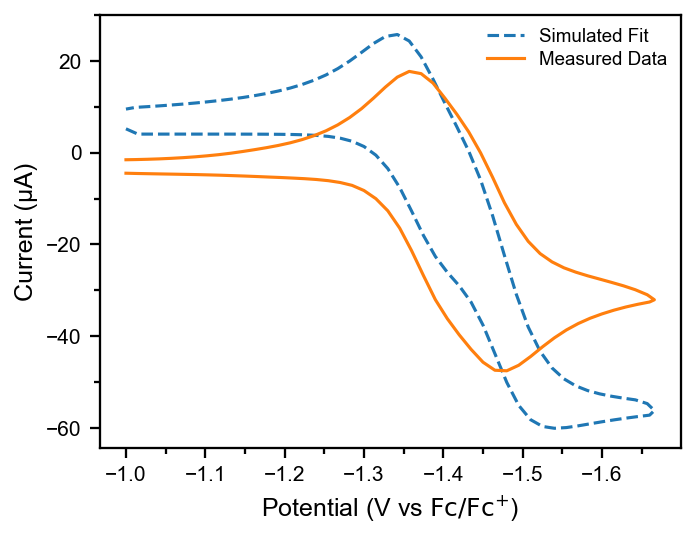

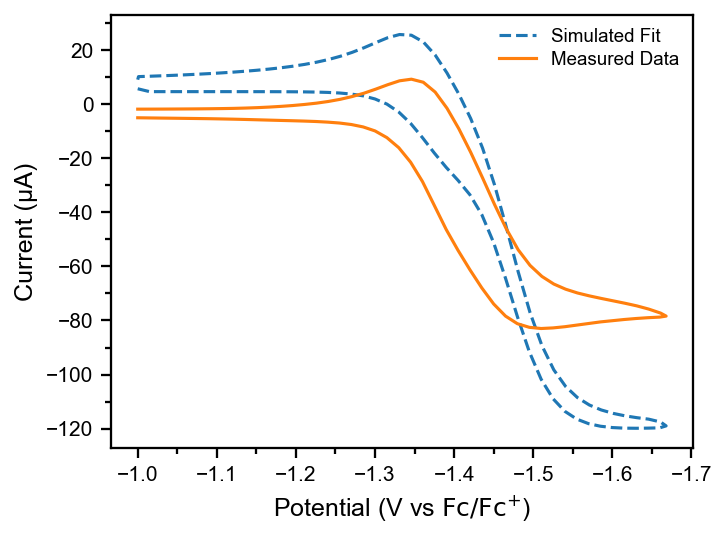

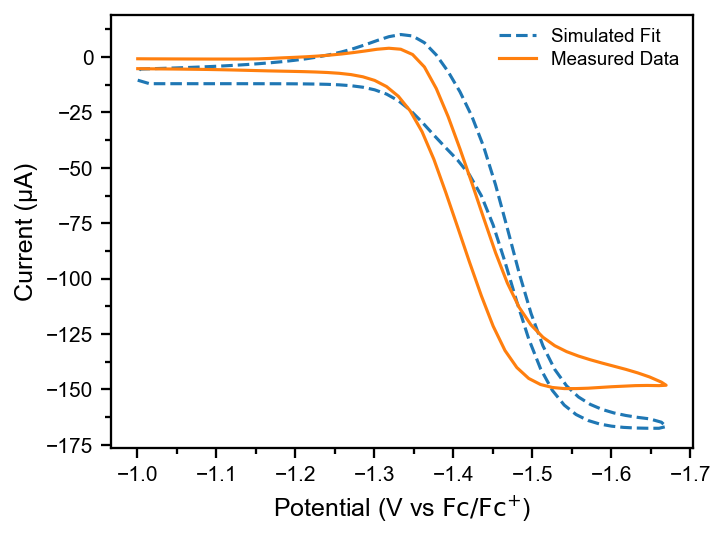

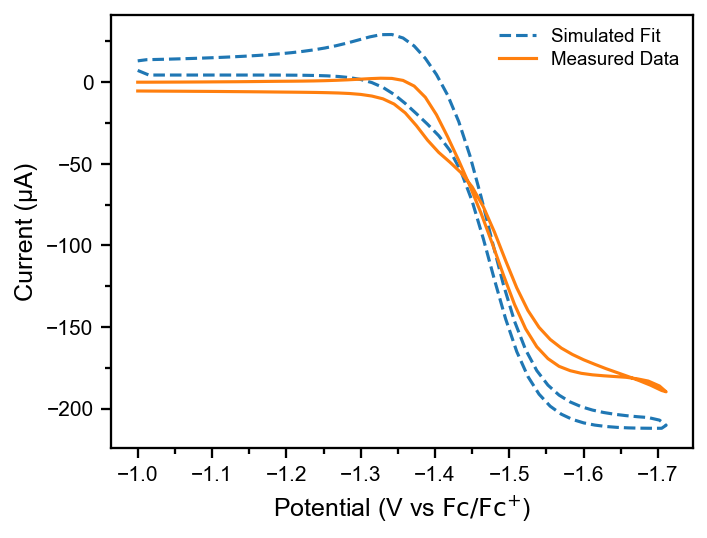

In [7]:
ecat_group_fit = None
if group_params is None:
    print("SKIP: CO2/PhOH concentration group fit needs the EEC' starting params.")
else:
    ecat_group_fit = e.simulation.fit_cvs(
        phoh_group_scaled,
        eecat_mechanism,
        group_params,
        fit={
            "vary": ["reactions.0.kf"],
            "fixed": {"alpha_*": 0.5, "k0_*": 1e-3},
            "bounds": "auto",
            "transform": "auto",
        },
        per_cv=["cell.Cdl", "cell.Ru", "concentrations.bulk.Substrate"],
        options={
            "cv data": {**PHOH_CV_WINDOW_OPTIONS, "stride": CO2_FIT_STRIDE, "estimate Cdl": "auto"},
            "concentration mapping": {"PhOH": "Substrate"},
            "plot": True,
            "post correction": "offset",
            "print setup": True,
            "print stats": True,
            "print corrections": True,
            "print params": True,
            "print progress": False,
            "print simulation": False,
        },
    )

## Reporting Notes

For group fits, report which parameters are shared, which paths are per-CV, the concentration mapping, the residual correction mode, and whether fixed per-CV values came from source CV metadata or from explicit parameters.
